# 🤖 Self-Evaluating AI Agent for Data Pipeline Incidents

## 🎯 Problem Statement
Data pipeline failures require **3+ hours** of expert manual analysis, causing:
- Delayed incident response
- Costly downtime 
- Manual expert intervention for every failure

## 💡 Solution: Self-Evaluating Agent Framework
AI agent that **evaluates its own work** and **learns from human feedback**:

## 🎬 Demo: Three Real Scenarios
**Scenario 1**: Database timeout → Agent correctly identifies → APPROVE

**Scenario 2**: Memory exhaustion → Agent misses → Human corrects → MODIFY  

**Scenario 3**: Data corruption → Too complex → ESCALATE to security team

---
**Statement 2: Evaluation and Reliability** ✅ 
*Building agents that evaluate their own work and get smarter over time*

## 0 Initialization

In [1]:
import json
import pandas as pd
from datetime import datetime

from typing import TypedDict, Dict, Any, List
from typing_extensions import Literal

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, END
from langgraph.types import Command, interrupt
from langchain_ollama import ChatOllama

In [2]:
# Initialize the Ollama model
model = ChatOllama(
    model="llama3.2:latest",
    temperature=0.1,  # Low temperature for consistent analysis
    base_url="http://host.docker.internal:11434",
)

## 1.0 mock data

In [3]:
dqc_alert = {
        "severity": "CRITICAL",
        "check_type": "report_readiness_check", 
        "table": "daily_transaction_report",
        "time_period": "2025-06-01T02:53:32.136584",
        "expected_value": "READY",
        "actual_value": "NOT_READY"
    }
with open('data/table_metadata_20250601_045332.json', 'r') as f:
    TABLE_METADATA = json.load(f)

with open('data/airflow_logs_20250601_045332.json', 'r') as f:
    AIRFLOW_LOGS  = json.load(f)

with open('data/dqc_logs_20250601_045332.json', 'r') as f:
    DQC_LOGS = json.load(f)

## 2.0 Agent func

In [4]:
# State definition
class IncidentState(TypedDict):
    alert: Dict[str, Any]
    table_context: Dict[str, Any] 
    related_logs: List[Dict[str, Any]]
    llm_analysis: Dict[str, Any]
    human_review: Dict[str, Any]
    final_recommendation: Dict[str, Any]

In [5]:
# node 1
def get_table_context(state: IncidentState) -> IncidentState:
    print("🔍 NODE 1: Getting table context and data lineage...")
    
    alert = state["alert"]
    table_name = alert.get('table')
    print(f"alert: {alert}, table_name: {table_name}")
    
    if table_name not in TABLE_METADATA:
        print(f"   ❌ Table {table_name} not found in metadata")
        state["table_context"] = {"error": f"Table {table_name} not found"}
        return state
    
    table_info = TABLE_METADATA[table_name]
    
    context = {
        "table_name": table_name,
        "database": table_info['table_info']['database'],
        "owner": table_info['table_info']['owner'],
        "description": table_info['table_info']['description'],
        "upstream_dependencies": table_info['data_lineage']['upstream_dependencies'],
        "downstream_consumers": table_info['data_lineage']['downstream_consumers'],
        "sla_requirements": table_info['sla_requirements'],
    }
    
    print(f"   ✅ Found metadata for table: {table_name}")
    print(f"   ✅ Upstream deps: {[dep['source'] for dep in context['upstream_dependencies']]}")
    print(context)
    print("."* 100)
    state["table_context"] = context
    return state

In [6]:
# node 2
def get_related_logs(state: IncidentState) -> IncidentState:
    print("\n📋 NODE 2: Getting related Airflow logs...")
    
    alert = state["alert"]
    table_context = state["table_context"]
    # print("."* 100)
    print(f"alert: {alert}, table_context: {table_context}")
    
    if "error" in table_context:
        state["related_logs"] = []
        return state
    
    table_name = alert.get('table')
    alert_time = alert.get('time_period', '')
    alert_date = alert_time.split('T')[0] if alert_time else '2025-06-01'
    
    upstream_sources = [dep['source'] for dep in table_context.get('upstream_dependencies', [])]
    
    print(f"   🔍 Looking for logs related to: {table_name}")
    print(f"   🔍 And upstream dependencies: {upstream_sources}")
    print(f"   🔍 Around date: {alert_date}")
    
    related_logs = []
    
    for log in AIRFLOW_LOGS:
        log_time = log.get('timestamp', '')
        dag_id = log.get('dag_id', '')
        message = log.get('message', '')
        task_id = log.get('task_id', '')
        
        # Check if log is relevant
        is_relevant = False
        
        # 1. Must be from the same date
        if alert_date in log_time:
            # 2. Check if related to our table or its dependencies
            if (table_name.replace('_', '-') in dag_id or
                'transaction' in dag_id or  # Related pipeline
                any(source in message.lower() for source in upstream_sources) or
                any(source in task_id.lower() for source in upstream_sources)):
                is_relevant = True

        if is_relevant:
            related_logs.append(log)
    
    related_logs.sort(key=lambda x: x.get('timestamp', ''))
    print(f"   ✅ Found {len(related_logs)} related logs")
    print("."* 100)
    state["related_logs"] = related_logs
    return state

In [7]:
# node 3
def call_llm_analysis(state: IncidentState) -> IncidentState:
    """
    Node 3: Use LLM to analyze the incident context and logs
    """
    print("\n🤖 NODE 3: LLM Analysis and Reasoning...")
    
    alert = state["alert"]
    table_context = state["table_context"]
    related_logs = state["related_logs"]
    human_review = state.get("human_review", {})

    # Check if this is a re-run due to human feedback
    is_rerun = bool(human_review.get("action") == "modify")
    
    if is_rerun:
        print("   🔄 Re-running analysis with human feedback...")
    else:
        print("   🆕 Initial analysis...")

    
    # Prepare context for LLM
    context_prompt = f"""
You are an expert data engineer analyzing a critical incident. Please analyze the following information and provide insights:

INCIDENT ALERT:
- Severity: {alert.get('severity')}
- Check Type: {alert.get('check_type')}
- Table: {alert.get('table')}
- Expected Value: {alert.get('expected_value')}
- Actual Value: {alert.get('actual_value')}
- Time: {alert.get('time_period')}

TABLE CONTEXT: {table_context}
RELATED LOGS: {related_logs}
"""

    if is_rerun:
        context_prompt += f"""

HUMAN FEEDBACK FROM PREVIOUS ANALYSIS:
- Action: {human_review.get('action')}
- Feedback: {human_review.get('feedback', 'No specific feedback')}
- Root Cause Override: {human_review.get('root_cause_override', 'None')}
- Technical Impact Override: {human_review.get('impact_override', 'None')}
- Business Impact Override: {human_review.get('business_impact_override', 'None')}
- Additional Recommendations: {human_review.get('recommendations_override', 'None')}

IMPORTANT: Please incorporate the human feedback above into your analysis. 
Address any concerns or corrections mentioned in the feedback.
"""

    analysis_prompt = context_prompt + """
Please provide a structured analysis with the following:

1. ROOT CAUSE ANALYSIS:
   - What is the most likely root cause?
   - What evidence supports this conclusion?
   - Confidence level (1-10)

2. TIMELINE RECONSTRUCTION:
   - Key events leading to the failure
   - Critical decision points

3. IMPACT ASSESSMENT:
   - Immediate impact on data pipeline
   - Downstream systems affected
   - Business impact severity

4. RECOMMENDATIONS:
   - Immediate actions to resolve
   - Preventive measures for future
   - Monitoring improvements

5. ESCALATION DECISION:
   - Should this be escalated to senior engineers?
   - Required skill sets for resolution

Please be specific and actionable in your recommendations.
"""
    try:
        # Call LLM for analysis
        print("   🔄 Sending context to LLM...")
        response = model.invoke(analysis_prompt)
        # print("\n")
        # print(response)
        
        llm_analysis = {
            "timestamp": json.dumps(alert.get('time_period')),
            "prompt_used": analysis_prompt,
            "llm_response": response.content,
            "model_used": "llama3.2:latest",
            "context_size": len(analysis_prompt),
            "logs_analyzed": len(related_logs)
        }
        
        print(f"   ✅ LLM analysis completed")
        print(f"   ✅ Response length: {len(response.content)} characters")
        print(f"   ✅ Context analyzed: {len(related_logs)} logs")
        
    except Exception as e:
        print(f"   ❌ LLM analysis failed: {str(e)}")
        llm_analysis = {
            "error": str(e),
            "fallback_message": "LLM analysis unavailable - using rule-based analysis"
        }
    
    state["llm_analysis"] = llm_analysis
    print("."* 100)
    return state

In [8]:
# Node 4: Human Review with Interrupt
def human_review_node(state: IncidentState) -> IncidentState:
    """
    Node 4: Human-in-the-loop evaluation of LLM analysis
    """
    print("\n👤 NODE 4: Human Review (Interrupt)...")
    
    llm_analysis = state["llm_analysis"]
    alert = state["alert"]
    
    # Show LLM analysis for review
    print("📊 LLM ANALYSIS FOR REVIEW:")
    print("-" * 50)
    if llm_analysis.get('llm_response'):
        print(llm_analysis['llm_response'])

    else:
        print("No LLM analysis available")
    print("-" * 50)

    return state
    
# Node 6
def escalate_to_experts(state: IncidentState) -> IncidentState:
    """
    Node for escalation scenarios
    """
    print("\n🚨 NODE 6: Escalating to Expert Team...")
    
    alert = state["alert"]
    human_review = state["human_review"]
    
    escalation_report = {
        "incident_id": f"ESC-{alert.get('table')}-{alert.get('time_period', '').replace(':', '').replace('-', '')}",
        "timestamp": alert.get('time_period'),
        "severity": "ESCALATED",
        "escalation_reason": human_review.get('feedback', 'Complex issue requiring expert analysis'),
        "assigned_team": "Senior Data Engineering",
        "priority": "HIGH",
        "estimated_resolution": "2-4 hours with expert involvement",
        "escalation_required": True,
        "status": "escalated_to_experts",
        "next_steps": [
            "Senior engineer to review within 30 minutes",
            # "Security team notified if data integrity issue",
            "Incident commander assigned",
            "Regular updates every hour"
        ]
    }
    
    print(f"   ✅ Escalated: {escalation_report['incident_id']}")
    print(f"   ✅ Assigned to: {escalation_report['assigned_team']}")
    
    state["final_recommendation"] = escalation_report
    print("-" * 50)
    return state

In [9]:
from helper.mongo import save_incident_to_mongodb

# Node 5
def generate_final_report(state: IncidentState) -> IncidentState:
    """
    Node 5: Generate comprehensive final root cause analysis report
    """
    print("\n📋 NODE 5: Generating Final Root Cause Report...")
    
    alert = state["alert"]
    table_context = state["table_context"]
    llm_analysis = state["llm_analysis"]
    human_review = state["human_review"]
    related_logs = state["related_logs"]
    
    # Generate unique incident ID
    timestamp = alert.get('time_period', '').replace(':', '').replace('-', '').replace('T', '-').replace('.', '')
    incident_id = f"INC-{alert.get('table', 'UNKNOWN')}-{timestamp[:15]}"
    
    # Extract key information from LLM analysis
    llm_response = llm_analysis.get('llm_response', '')
    
    # Parse LLM analysis sections (basic parsing)
    def extract_section(text, section_name):
        try:
            start = text.find(f"**{section_name}**")
            if start == -1:
                return "Not found in LLM analysis"
            
            # Find next section or end
            next_section = text.find("**", start + len(section_name) + 4)
            if next_section == -1:
                section_text = text[start:]
            else:
                section_text = text[start:next_section]
            
            return section_text.replace(f"**{section_name}**", "").strip()
        except:
            return "Error parsing LLM analysis"
    
    # Use human overrides if provided, otherwise use LLM analysis
    root_cause = human_review.get("root_cause_override") or extract_section(llm_response, "ROOT CAUSE ANALYSIS")
    impact_assessment = human_review.get("impact_override") or extract_section(llm_response, "IMPACT ASSESSMENT")
    recommendations = human_review.get("recommendations_override") or extract_section(llm_response, "RECOMMENDATIONS")
    timeline = extract_section(llm_response, "TIMELINE RECONSTRUCTION")
    
    # Generate comprehensive report
    final_report = {
        # Header Information
        "incident_id": incident_id,
        "generated_at": datetime.now().isoformat(),
        "severity": alert.get('severity'),
        "status": "analysis_complete",
        "escalation_required": human_review.get('action') == 'escalate',
        
        # Incident Details
        "incident_summary": {
            "alert_type": alert.get('check_type'),
            "affected_table": alert.get('table'),
            "database": table_context.get('database'),
            "owner": table_context.get('owner'),
            "time_detected": alert.get('time_period'),
            "expected_value": alert.get('expected_value'),
            "actual_value": alert.get('actual_value')
        },
        
        # Technical Analysis
        "technical_analysis": {
            "root_cause": root_cause,
            "timeline_reconstruction": timeline,
            "logs_analyzed": len(related_logs),
            "upstream_dependencies": [dep['source'] for dep in table_context.get('upstream_dependencies', [])],
            "downstream_consumers": table_context.get('downstream_consumers', [])
        },
        
        # Impact Assessment
        "impact_assessment": {
            "technical_impact": impact_assessment,
            "business_impact": human_review.get("business_impact_override") or "Downstream reporting and dashboards affected",
            "affected_systems": table_context.get('downstream_consumers', []),
            "sla_breach": {
                "max_delay_tolerance": table_context.get('sla_requirements', {}).get('max_delay_tolerance'),
                "availability_target": table_context.get('sla_requirements', {}).get('availability_target')
            }
        },
        
        # Resolution
        "resolution": {
            "recommended_actions": recommendations,
            "human_validation": {
                "action": human_review.get('action', 'unknown'),
                "feedback": human_review.get('feedback', ''),
                "confidence": "High" if human_review.get('action') == 'approve' else "Requires review"
            },
            "llm_confidence": extract_section(llm_response, "ROOT CAUSE ANALYSIS").split("Confidence level:")[-1].split("\n")[0].strip() if "Confidence level:" in llm_response else "Not specified"
        },
        
        # Audit Trail
        "audit_trail": {
            "llm_model": llm_analysis.get('model_used', 'Unknown'),
            "analysis_timestamp": llm_analysis.get('timestamp'),
            "human_review_timestamp": datetime.now().isoformat(),
            "context_size": llm_analysis.get('context_size', 0),
            "logs_analyzed_count": len(related_logs)
        },
        
        # Next Steps
        "next_steps": {
            "immediate_actions": [
                "Investigate root cause identified by analysis",
                "Verify downstream system impacts",
                "Implement recommended fixes"
            ] if human_review.get('action') == 'approve' else [
                "Senior engineer review required",
                "Escalation process initiated"
            ],
            "preventive_measures": [
                "Review monitoring thresholds",
                "Implement additional data quality checks",
                "Update incident response procedures"
            ],
            "follow_up_required": human_review.get('action') != 'approve'
        }
    }
    
    # Generate human-readable summary
    summary_text = f"""
INCIDENT REPORT SUMMARY
=======================
Incident ID: {incident_id}
Severity: {alert.get('severity')}
Table: {alert.get('table')}
Status: {final_report['status']}

ROOT CAUSE:
{root_cause[:200]}...

RECOMMENDED ACTIONS:
{recommendations[:200]}...

HUMAN VALIDATION: {human_review.get('action', 'unknown').upper()}
ESCALATION REQUIRED: {'YES' if final_report['escalation_required'] else 'NO'}
"""
    
    final_report["summary_text"] = summary_text
    
    print(f"   ✅ Final report generated: {incident_id}")
    print(f"   ✅ Human decision: {human_review.get('action', 'unknown')}")
    print(f"   ✅ Report sections: {len(final_report)} main sections")

    save_incident_to_mongodb(final_report)
    # # Save report to file
    # try:
    #     output_file = f"incident_report/incident_report_{incident_id}.json"
    #     with open(output_file, 'w') as f:
    #         json.dump(final_report, f, indent=2, default=str)
    #     print(f"   💾 Report saved to: {output_file}")
    # except Exception as e:
    #     print(f"   ⚠️  Could not save report: {e}")
    
    state["final_recommendation"] = final_report
    print("." * 100)
    return state

In [10]:
def route_after_human_review(state: IncidentState) -> Literal["call_llm_analysis", "generate_final_report"]:
    """
    Route based on human decision
    """
    human_action = state["human_review"].get("action", "approve")
    
    if human_action == "modify":
        print("   🔄 Routing to: Re-run LLM analysis")
        return "call_llm_analysis"
    elif human_action == "approve":
        print("   ✅ Routing to: Generate final report")
        return "generate_final_report"
    elif human_action == "escalate":
        print("   🚨 Routing to: Escalate to experts")
        return "escalate_to_experts"
    else:
        print("   ⚠️ Unknown action, defaulting to: Generate final report")
        return "generate_final_report"

In [11]:
workflow = StateGraph(IncidentState)
# Add all four nodes
workflow.add_node("get_table_context", get_table_context)
workflow.add_node("get_related_logs", get_related_logs)
workflow.add_node("call_llm_analysis", call_llm_analysis)
workflow.add_node("human_review_node", human_review_node)
workflow.add_node("generate_final_report", generate_final_report)
workflow.add_node("escalate_to_experts", escalate_to_experts)

# Set up the flow: start with table context, then get logs
workflow.set_entry_point("get_table_context")
workflow.add_edge("get_table_context", "get_related_logs")
workflow.add_edge("get_related_logs", "call_llm_analysis")
workflow.add_edge("call_llm_analysis", "human_review_node")
workflow.add_conditional_edges(
    "human_review_node",
    route_after_human_review,
    {
        "call_llm_analysis": "call_llm_analysis",
        "generate_final_report": "generate_final_report",
        "escalate_to_experts": "escalate_to_experts" 
    }
)
workflow.add_edge("generate_final_report", END)
workflow.add_edge("escalate_to_experts", END)
memory = MemorySaver()

app = workflow.compile(interrupt_before=["human_review_node"], checkpointer=memory)

## 3. Agent workflow

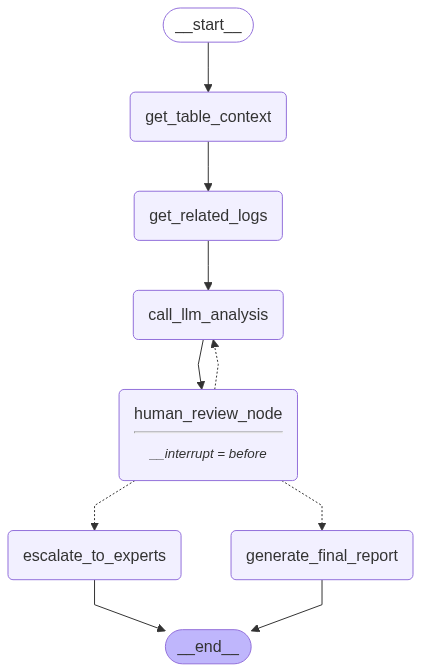

In [12]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

## DEMO

### Scenario 1: Approved

In [13]:
from example.demo import demo_scenario_1_approve, demo_scenario_2_modify, demo_scenario_3_escalate

In [14]:
alert = demo_scenario_1_approve()
alert

🎯 SCENARIO 1: APPROVE (Database Timeout)
Alert: Daily transaction report failed
Expected LLM to identify: Database connection timeout


{'severity': 'CRITICAL',
 'check_type': 'report_readiness_check',
 'table': 'daily_transaction_report',
 'time_period': '2025-06-01T02:53:32.136584',
 'expected_value': 'READY',
 'actual_value': 'NOT_READY'}

In [15]:
from helper.agent import invoke_agent, debug_tracing, handle_workflow_with_interrupts
from helper.input import get_cli_input_auto

thread_id = "demo_scenario_approved"
# config = {"configurable": {"thread_id": thread_id}}
paused_state = invoke_agent(app, alert,thread_id)

print("🛑 PAUSED AT INTERRUPT")
print("📊 Review the LLM analysis above")

print("\n" + "🎤" * 20 + " LIVE HUMAN INPUT " + "🎤" * 20)
human_feedback = get_cli_input_auto(scenario_num=1, demo_mode=True)


🔄 Running agent analysis...
🔍 NODE 1: Getting table context and data lineage...
alert: {'severity': 'CRITICAL', 'check_type': 'report_readiness_check', 'table': 'daily_transaction_report', 'time_period': '2025-06-01T02:53:32.136584', 'expected_value': 'READY', 'actual_value': 'NOT_READY'}, table_name: daily_transaction_report
   ✅ Found metadata for table: daily_transaction_report
   ✅ Upstream deps: ['raw_transactions', 'merchant_data']
{'table_name': 'daily_transaction_report', 'database': 'reporting_db', 'owner': 'data_engineering_team', 'description': 'Daily aggregated transaction report with merchant and payment details', 'upstream_dependencies': [{'source': 'raw_transactions', 'database': 'transaction_db', 'update_frequency': 'real-time', 'critical': True}, {'source': 'merchant_data', 'database': 'master_data_db', 'update_frequency': 'daily', 'critical': True}], 'downstream_consumers': ['daily_summary_report', 'business_dashboard', 'regulatory_reports'], 'sla_requirements': {'up

In [16]:
debug_tracing(app, thread_id)

Memory state for demo_scenario_approved:
  Next nodes: ('human_review_node',)
Current values keys: ['alert', 'table_context', 'related_logs', 'llm_analysis', 'human_review', 'final_recommendation']


In [17]:
final_result = handle_workflow_with_interrupts(app, thread_id, human_feedback)


👤 NODE 4: Human Review (Interrupt)...
📊 LLM ANALYSIS FOR REVIEW:
--------------------------------------------------
**ROOT CAUSE ANALYSIS**

Based on the provided information, the most likely root cause of the critical incident is:

* **Incomplete upstream data source 'merchant_data'**

Evidence supporting this conclusion includes:

* The actual value reported by the `report_readiness_check` task is `NOT_READY`, indicating that the report is not ready due to incomplete merchant data.
* The error message from the `check_validator` task mentions that the report readiness check failed because the upstream data source 'merchant_data' is incomplete.
* The warning log from the `data_validator` task indicates that the report will be marked as `NOT_READY` if merchant data is missing.

Confidence level: 9/10

**TIMELINE RECONSTRUCTION**

Key events leading to the failure:

1. **02:23:32**: The `daily_transaction_pipeline` DAG starts, and the `extract_merchant_data` task begins.
2. **02:28:32**

### Scenario2: Modify

In [ ]:
alert = demo_scenario_2_modify()
alert

In [ ]:
from helper.agent import invoke_agent, debug_tracing
from helper.input import get_cli_input_auto

thread_id = "demo_scenario_modify"
# config = {"configurable": {"thread_id": thread_id}}
paused_state = invoke_agent(app, alert,thread_id)

print("🛑 PAUSED AT INTERRUPT")
print("📊 Review the LLM analysis above")

print("\n" + "🎤" * 20 + " LIVE HUMAN INPUT " + "🎤" * 20)
human_feedback = get_cli_input_auto(scenario_num=2, demo_mode=True)

In [ ]:
debug_tracing(app, thread_id)

In [ ]:
final_result = handle_workflow_with_interrupts(app, thread_id, human_feedback)

### Scenario 3: Escalate

In [ ]:
alert = demo_scenario_3_escalate()
alert

In [ ]:
from helper.agent import invoke_agent, debug_tracing
from helper.input import get_cli_input_auto

thread_id = "demo_scenario_escalate"
# config = {"configurable": {"thread_id": thread_id}}
paused_state = invoke_agent(app, alert,thread_id)

print("🛑 PAUSED AT INTERRUPT")
print("📊 Review the LLM analysis above")

print("\n" + "🎤" * 20 + " LIVE HUMAN INPUT " + "🎤" * 20)
human_feedback = get_cli_input_auto(scenario_num=3, demo_mode=True)

In [ ]:
debug_tracing(app, thread_id)

In [ ]:
final_result = handle_workflow_with_interrupts(app, thread_id, human_feedback)

## Summary

### ✨ Key Innovation: Agent Self-Evaluation
- **Confidence assessment**: Agent knows when it's uncertain (8/10, 9/10)
- **Human-in-the-loop**: Requests review when needed
- **Self-correction**: Learns from human feedback via modify loops
- **Smart escalation**: Knows when issues require experts

### 🔄 Three Evaluation Workflows
1. **APPROVE**: Agent gets it right → Human approves → Auto-execute
2. **MODIFY**: Agent misses something → Human corrects → Agent learns
3. **ESCALATE**: Complex issue → Human escalates → Expert team

### 🏗️ Technical Architecture
- **LangGraph**: State management with memory checkpointing
- **Conditional routing**: Approve/Modify/Escalate logic
- **Task-agnostic**: Works beyond data pipelines
- **Audit trail**: Complete incident reports

## 🎬 Demo: Three Real Scenarios
**Scenario 1**: Database timeout → Agent correctly identifies → APPROVE
**Scenario 2**: Memory exhaustion → Agent misses → Human corrects → MODIFY  
**Scenario 3**: Data corruption → Too complex → ESCALATE to security team

## 📈 Impact
- **Time savings**: 4+ hours → 5 minutes
- **Accuracy**: Improves through human feedback
- **Scalability**: Self-evaluating framework for any domain
- **Reliability**: Handles long-running incident response tasks
